# 1. Price Prediction from Batting Stats

R² Score: 0.27
RMSE: 316135.83


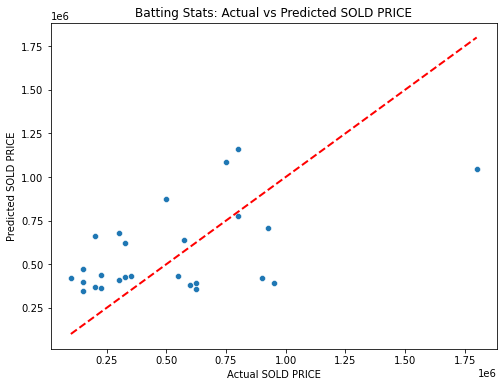

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("IPL DATA2013.csv")

# Select batting features
batting_features = ['RUNS-S', 'HS', 'SR-B', 'SIXERS']
X_bat = df[batting_features]
y_price = df['SOLD PRICE']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_bat, y_price, test_size=0.2, random_state=42)

# Train model
model_bat = LinearRegression()
model_bat.fit(X_train, y_train)

# Predictions on test set
y_pred_bat = model_bat.predict(X_test)

# Evaluate
r2_bat = r2_score(y_test, y_pred_bat)
rmse_bat = mean_squared_error(y_test, y_pred_bat, squared=False)

print(f"R² Score: {r2_bat:.2f}")
print(f"RMSE: {rmse_bat:.2f}")

# Scatter plot: Actual vs Predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_bat)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # reference line
plt.xlabel("Actual SOLD PRICE")
plt.ylabel("Predicted SOLD PRICE")
plt.title("Batting Stats: Actual vs Predicted SOLD PRICE")
plt.show()


# 2. Price Prediction from Bowling Stats 

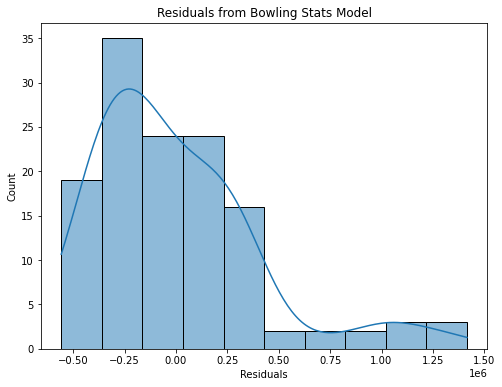

Feature Contributions:
 AVE-BL    10293.261105
WKTS       1229.320906
SR-BL     -8958.408056
ECON      -9888.104432
dtype: float64


In [17]:
bowling_features = ['WKTS', 'AVE-BL', 'ECON', 'SR-BL']
X_bowl = df[bowling_features]

model_bowl = LinearRegression()
model_bowl.fit(X_bowl, y_price)
y_pred_bowl = model_bowl.predict(X_bowl)

# Coefficients
coeffs = pd.Series(model_bowl.coef_, index=bowling_features)

# Residuals
residuals = y_price - y_pred_bowl

# Plot residuals
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)
plt.title("Residuals from Bowling Stats Model")
plt.xlabel("Residuals")
plt.show()

print("Feature Contributions:\n", coeffs.sort_values(ascending=False))


# 3. Base Price vs Sold Price Relationship 

Mean Absolute Error: 269147.37


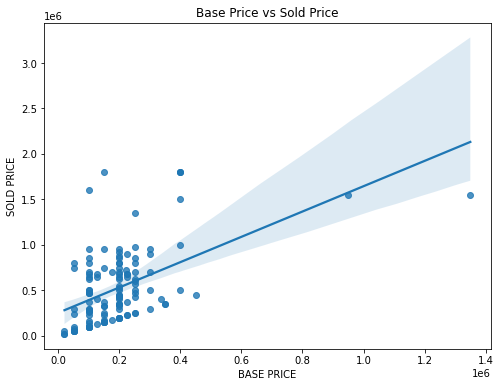

In [18]:
from sklearn.metrics import mean_absolute_error

X_base = df[['BASE PRICE']]
model_base = LinearRegression()
model_base.fit(X_base, y_price)
y_pred_base = model_base.predict(X_base)

mae = mean_absolute_error(y_price, y_pred_base)
print(f"Mean Absolute Error: {mae:.2f}")

# Regression line plot
plt.figure(figsize=(8,6))
sns.regplot(x='BASE PRICE', y='SOLD PRICE', data=df)
plt.title("Base Price vs Sold Price")
plt.show()


# 4. Multi-feature Model for Auction Price

Multi-feature R²: 0.28, RMSE: 344991.08


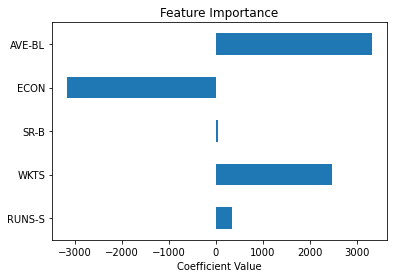

In [20]:
multi_features = ['RUNS-S', 'WKTS', 'SR-B', 'ECON', 'AVE-BL']
X_multi = df[multi_features]

model_multi = LinearRegression()
model_multi.fit(X_multi, y_price)
y_pred_multi = model_multi.predict(X_multi)

r2_multi = r2_score(y_price, y_pred_multi)
rmse_multi = mean_squared_error(y_price, y_pred_multi, squared=False)

print(f"Multi-feature R²: {r2_multi:.2f}, RMSE: {rmse_multi:.2f}")

# Feature importance
coeffs_multi = pd.Series(model_multi.coef_, index=multi_features)
coeffs_multi.plot(kind='barh', title="Feature Importance")
plt.xlabel("Coefficient Value")
plt.show()


# 5. Age Impact on Price

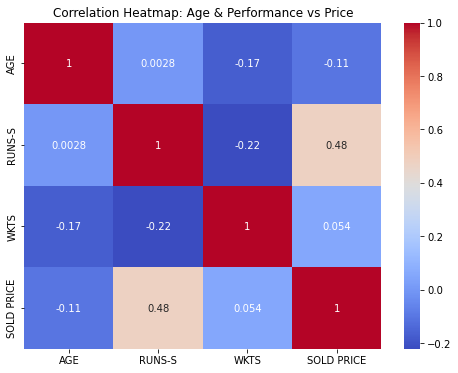

In [21]:
age_features = ['AGE', 'RUNS-S', 'WKTS']
X_age = df[age_features]

model_age = LinearRegression()
model_age.fit(X_age, y_price)

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[age_features + ['SOLD PRICE']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap: Age & Performance vs Price")
plt.show()


# 6. Country-wise Price Prediction

SA: R² = 0.23
IND: R² = 0.28
AUS: R² = 0.37
WI: R² = 0.90
SL: R² = 0.25
NZ: R² = 0.22
PAK: R² = 0.12


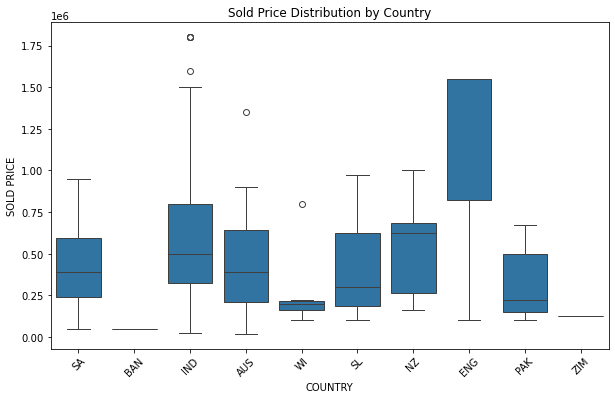

In [22]:
countries = df['COUNTRY'].unique()
for country in countries:
    subset = df[df['COUNTRY'] == country]
    if len(subset) > 5:
        X_country = subset[['RUNS-S', 'WKTS']]
        y_country = subset['SOLD PRICE']
        model_country = LinearRegression()
        model_country.fit(X_country, y_country)
        r2 = model_country.score(X_country, y_country)
        print(f"{country}: R² = {r2:.2f}")

# Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(x='COUNTRY', y='SOLD PRICE', data=df)
plt.xticks(rotation=45)
plt.title("Sold Price Distribution by Country")
plt.show()


# 7. Prediction of Strike Rate (Batting) 

Strike Rate Prediction R²: 0.31


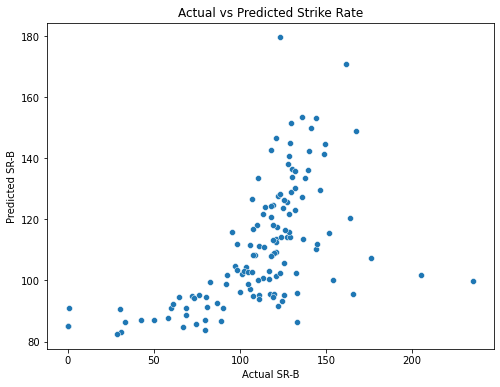

In [23]:
sr_features = ['RUNS-S', 'HS', 'SIXERS', 'AGE']
X_sr = df[sr_features]
y_sr = df['SR-B']

model_sr = LinearRegression()
model_sr.fit(X_sr, y_sr)
y_pred_sr = model_sr.predict(X_sr)

r2_sr = r2_score(y_sr, y_pred_sr)
print(f"Strike Rate Prediction R²: {r2_sr:.2f}")

# Actual vs Predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_sr, y=y_pred_sr)
plt.xlabel("Actual SR-B")
plt.ylabel("Predicted SR-B")
plt.title("Actual vs Predicted Strike Rate")
plt.show()
